# 02 - Data Audit

## Objective

Before building the onboarding funnel or evaluating downstream behavior, audit the raw tables for structural, business-rule, and temporal consistency.

The goal is not to "clean away" unusual records. It is to identify issues, decide whether they are expected or analytically relevant, and carry them forward explicitly.

In [1]:
import pandas as pd
from IPython.display import display

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [3]:
captains = pd.read_csv("../data/captains.csv")
doc_events = pd.read_csv("../data/doc_events.csv")
approvals = pd.read_csv("../data/approvals.csv")
activation = pd.read_csv("../data/activation.csv")
nudges = pd.read_csv("../data/nudges.csv")
airport_hourly = pd.read_csv("../data/airport_hourly.csv")
airport_trips = pd.read_csv("../data/airport_trips.csv")

In [4]:
datasets = {
    "captains": captains,
    "doc_events": doc_events,
    "approvals": approvals,
    "activation": activation,
    "nudges": nudges,
    "airport_hourly": airport_hourly,
    "airport_trips": airport_trips
}

In [5]:
for name, df in datasets.items():
    print(f"{name:15s}: {df.shape}")

captains       : (25000, 9)
doc_events     : (186282, 7)
approvals      : (25000, 5)
activation     : (4206, 5)
nudges         : (16314, 6)
airport_hourly : (10248, 9)
airport_trips  : (60000, 9)


## 1. Structural Integrity

First, check the identifiers that define the grain of each table. These checks help distinguish a genuine data issue from a table that simply contains multiple events per captain.

In [6]:
key_checks = {
    "captains": ("captain_id", captains),
    "doc_events": ("event_id", doc_events),
    "approvals": ("captain_id", approvals),
    "activation": ("captain_id", activation),
    "airport_trips": ("trip_id", airport_trips),
}

In [7]:
for name, (key, df) in key_checks.items():
    print(
        f"{name:15s} | "
        f"unique {key}: {df[key].nunique():,} / {len(df):,} | "
        f"duplicates: {df[key].duplicated().sum():,}"
    )

captains        | unique captain_id: 25,000 / 25,000 | duplicates: 0
doc_events      | unique event_id: 186,282 / 186,282 | duplicates: 0
approvals       | unique captain_id: 25,000 / 25,000 | duplicates: 0
activation      | unique captain_id: 4,206 / 4,206 | duplicates: 0
airport_trips   | unique trip_id: 60,000 / 60,000 | duplicates: 0


In [8]:
print("\nExpected multi-row tables:")
print(f"doc_events  : {doc_events.groupby('captain_id').size().gt(1).sum():,} captains have multiple document events")
print(f"nudges      : {nudges.groupby('captain_id').size().gt(1).sum():,} captains have multiple nudge records")


Expected multi-row tables:
doc_events  : 23,251 captains have multiple document events
nudges      : 2,647 captains have multiple nudge records


In [9]:
duplicate_rows = {
    name: int(df.duplicated().sum())
    for name, df in datasets.items()
}

In [10]:
print("Full-row duplicate counts:")
for name, count in duplicate_rows.items():
    print(f"{name:15s} {count:,}")

Full-row duplicate counts:
captains        0
doc_events      0
approvals       0
activation      0
nudges          0
airport_hourly  0
airport_trips   0


## 2. Document Event Lifecycle

Document events are event-level data, so a captain can appear many times. The checks below focus on whether the event history is chronologically and logically consistent.

In [11]:
captains["signup_ts"] = pd.to_datetime(captains["signup_ts"])
doc_events["event_ts"] = pd.to_datetime(doc_events["event_ts"])

In [12]:
doc_with_signup = doc_events.merge(
    captains[["captain_id", "signup_ts"]],
    on="captain_id",
    how="left",
    validate="many_to_one",
)

In [13]:
events_before_signup = doc_with_signup[
    doc_with_signup["event_ts"] < doc_with_signup["signup_ts"]
]

In [14]:
print(f"Document events before signup: {len(events_before_signup):,}")

Document events before signup: 0


In [15]:
attempt_sequences = (
    doc_events
    .groupby(["captain_id", "doc_type"])["attempt_no"]
    .apply(lambda x: sorted(x.dropna().unique()))
    .reset_index(name="attempt_sequence")
)

In [16]:
attempt_sequences["has_gap"] = attempt_sequences["attempt_sequence"].apply(
    lambda seq: bool(seq) and seq != list(range(int(min(seq)), int(max(seq)) + 1))
)

In [17]:
print(
    "Captain-document combinations with attempt gaps:",
    int(attempt_sequences["has_gap"].sum())
)

Captain-document combinations with attempt gaps: 0


In [18]:
attempt_outcomes = (
    doc_events
    .groupby(["captain_id", "doc_type", "attempt_no"])["event_type"]
    .agg(lambda x: set(x.dropna()))
    .reset_index(name="events")
)

In [19]:
contradictory_attempts = attempt_outcomes[
    attempt_outcomes["events"].apply(
        lambda events: {"verification_pass", "verification_fail"}.issubset(events)
    )
]

In [20]:
print(
    "Attempts containing both verification pass and fail:",
    len(contradictory_attempts)
)

Attempts containing both verification pass and fail: 0


### Document event audit result

The event history is chronologically consistent with signup, with no pre-signup document events. Attempt numbers are sequential within each captain-document combination, and no attempt contains both a verification pass and verification fail.

These checks support using `doc_events` to reconstruct the onboarding journey without silently repairing event timestamps or attempt numbers.


## 3. Document Sequence

The expected onboarding order is:

**DL → RC → Aadhaar → Permit (Auto/Cab only) → Fitness → Insurance**

Because Permit is vehicle-dependent, the sequence check below uses the documents that actually appear for each captain rather than requiring Permit for every captain.

In [21]:
document_order = {
    "DL": 1,
    "RC": 2,
    "AADHAAR": 3,
    "PERMIT": 4,
    "FITNESS": 5,
    "INSURANCE": 6,
}

In [22]:
first_doc_events = (
    doc_events
    .assign(document_order=doc_events["doc_type"].map(document_order))
    .groupby(["captain_id", "doc_type"], as_index=False)
    .agg(
        first_event_ts=("event_ts", "min"),
        document_order=("document_order", "first"),
    )
    .sort_values(["captain_id", "first_event_ts"])
)

In [23]:
sequence_check = (
    first_doc_events
    .groupby("captain_id")["document_order"]
    .apply(list)
    .reset_index(name="observed_sequence")
)

In [24]:
sequence_check["has_sequence_violation"] = sequence_check[
    "observed_sequence"
].apply(lambda seq: seq != sorted(seq))

In [25]:
print(
    "Captains with document sequence violations:",
    int(sequence_check["has_sequence_violation"].sum())
)

Captains with document sequence violations: 0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

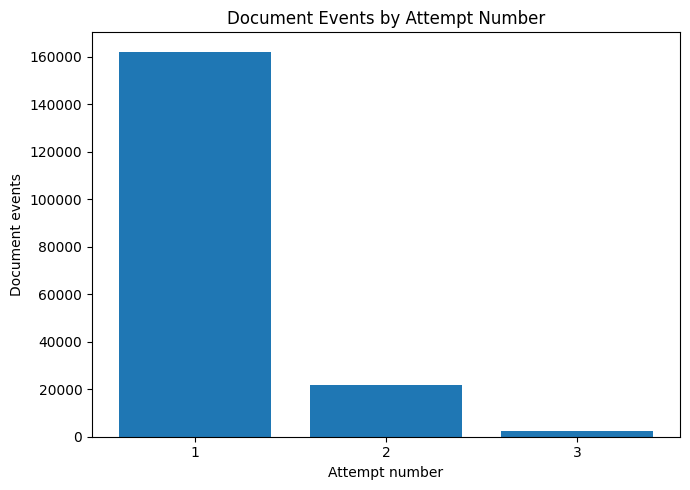

In [26]:
attempt_counts = (
    doc_events["attempt_no"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 5))

plt.bar(
    attempt_counts.index.astype(str),
    attempt_counts.values
)

plt.xlabel("Attempt number")
plt.ylabel("Document events")
plt.title("Document Events by Attempt Number")
plt.tight_layout()
plt.show()

### Why are we looking at this?

The onboarding process allows up to three document attempts. Before relying on document-event history for funnel reconstruction, it is useful to understand how events are distributed across attempts.

**What this tells us**

Most document events occur on the first attempt, with progressively fewer events on attempts 2 and 3. This is consistent with the expected retry structure and supports retaining attempt-level history for downstream funnel analysis.

The distribution also reinforces why document events cannot be treated as one row per captain: a single captain may generate multiple records across document types and retry attempts.

## 4. Document Applicability

Permit is required for Auto and Cab according to the assignment rules. This check has two parts:

1. Make sure Permit events do not appear for vehicle types that do not require them.
2. Quantify Auto/Cab captains with no Permit event.

The second result is **not automatically a data error**: a captain can leave the funnel before reaching the Permit stage.

In [27]:
permit_events = (
    doc_events[doc_events["doc_type"] == "PERMIT"]
    .merge(
        captains[["captain_id", "vehicle_type"]],
        on="captain_id",
        how="left",
        validate="many_to_one",
    )
)

In [28]:
permit_events["permit_expected"] = permit_events["vehicle_type"].isin(["Auto", "Cab"])

In [29]:
print("Permit events by applicability:")
display(
    permit_events["permit_expected"]
    .value_counts(dropna=False)
    .rename_axis("permit_expected")
    .to_frame("event_count")
)

Permit events by applicability:


,event_count
permit_expected,
True,20807


In [30]:
invalid_permit_events = permit_events[
    ~permit_events["permit_expected"]
]

print(
    "Permit events for vehicles where Permit is not required:",
    len(invalid_permit_events)
)

Permit events for vehicles where Permit is not required: 0


In [31]:
eligible_captains = captains[
    captains["vehicle_type"].isin(["Auto", "Cab"])
][["captain_id", "vehicle_type"]]

In [32]:
captains_with_permit = set(permit_events["captain_id"])

In [33]:
missing_permit = eligible_captains[
    ~eligible_captains["captain_id"].isin(captains_with_permit)
]

print(
    "Auto/Cab captains with no Permit event:",
    len(missing_permit)
)

Auto/Cab captains with no Permit event: 11031


In [34]:
sequence_check["has_sequence_violation"] = sequence_check[
    "observed_sequence"
].apply(
    lambda x: x != sorted(x)
)

print(
    "Captains with document sequence violations:",
    sequence_check["has_sequence_violation"].sum()
)

Captains with document sequence violations: 0


## 5. Approval and Activation Consistency

Activation is downstream of approval. Check that:

- every activation record belongs to an approved captain; and
- every approved captain has an activation record.

A valid activation row can still have a missing `first_order_ts`, because activation records capture post-approval activity rather than guaranteeing that a first order occurred.

In [35]:
approval_status = approvals[["captain_id", "final_status"]].copy()

In [36]:
activation_check = activation.merge(
    approval_status,
    on="captain_id",
    how="left",
    validate="one_to_one",
)

In [37]:
print("Activation records by final approval status:")
display(
    activation_check["final_status"]
    .value_counts(dropna=False)
    .rename_axis("final_status")
    .to_frame("activation_records")
)

Activation records by final approval status:


,activation_records
final_status,
approved,4206


In [38]:
invalid_activation = activation_check[
    activation_check["final_status"] != "approved"
]

print(
    "Activation records for non-approved captains:",
    len(invalid_activation)
)

Activation records for non-approved captains: 0


In [39]:
approved_captains = approvals.loc[
    approvals["final_status"] == "approved", "captain_id"
]

In [40]:
activation_captains = set(activation["captain_id"])

In [41]:
approved_without_activation = approved_captains[
    ~approved_captains.isin(activation_captains)
]

print(
    "Approved captains without an activation record:",
    len(approved_without_activation)
)

Approved captains without an activation record: 0


In [42]:
print(
    "Approved captains with a missing first_order_ts:",
    int(
        activation_check.loc[
            activation_check["final_status"] == "approved",
            "first_order_ts"
        ].isna().sum()
    )
)

Approved captains with a missing first_order_ts: 102


## 6. Cross-Table Temporal Consistency

The expected lifecycle is:

**signup → document processing → approval → first order**

The checks below look only for impossible timestamp relationships. Missing timestamps are not treated as violations.


In [43]:
approvals["decision_ts"] = pd.to_datetime(approvals["decision_ts"])
activation["first_order_ts"] = pd.to_datetime(activation["first_order_ts"])

In [44]:
lifecycle = (
    captains[["captain_id", "signup_ts"]]
    .merge(
        approvals[["captain_id", "decision_ts", "final_status"]],
        on="captain_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        activation[["captain_id", "first_order_ts"]],
        on="captain_id",
        how="left",
        validate="one_to_one",
    )
)

In [45]:
checks = {
    "approval_before_signup": (
        lifecycle["decision_ts"].notna()
        & (lifecycle["decision_ts"] < lifecycle["signup_ts"])
    ),
    "first_order_before_signup": (
        lifecycle["first_order_ts"].notna()
        & (lifecycle["first_order_ts"] < lifecycle["signup_ts"])
    ),
    "first_order_before_approval": (
        lifecycle["first_order_ts"].notna()
        & lifecycle["decision_ts"].notna()
        & (lifecycle["first_order_ts"] < lifecycle["decision_ts"])
    ),
}

In [46]:
for name, mask in checks.items():
    print(f"{name:30s}: {int(mask.sum()):,}")

approval_before_signup        : 0
first_order_before_signup     : 0
first_order_before_approval   : 0


In [47]:
# Document events after a captain's first order would also violate the expected lifecycle.
doc_order_check = doc_events[["captain_id", "event_ts"]].merge(
    activation[["captain_id", "first_order_ts"]],
    on="captain_id",
    how="inner",
    validate="many_to_one",
)

In [48]:
doc_after_order = doc_order_check[
    doc_order_check["first_order_ts"].notna()
    & (doc_order_check["event_ts"] > doc_order_check["first_order_ts"])
]

print("Document events after first order:", len(doc_after_order))

Document events after first order: 0


## 7. Known Data-Quality Anomalies

The following checks identify records that may affect downstream analysis. These are documented rather than deleted.


In [49]:
# Activation: D7 should not exceed D30 when both are observed.
d7_gt_d30 = activation[
    activation["orders_d7"].notna()
    & activation["orders_d30"].notna()
    & (activation["orders_d7"] > activation["orders_d30"])
]

print(f"Activation records with orders_d7 > orders_d30: {len(d7_gt_d30):,}")

Activation records with orders_d7 > orders_d30: 7


In [50]:
# Nudge: a click without delivery is logically unusual and needs interpretation.
click_without_delivery = nudges[
    (nudges["clicked"] == 1) & (nudges["delivered"] == 0)
]

print(f"Nudge records with clicked=1 but delivered=0: {len(click_without_delivery):,}")

Nudge records with clicked=1 but delivered=0: 457


In [51]:
# Approval decision timestamp is not populated for every status.
print("\nDecision timestamp missingness by final status:")
display(
    approvals.groupby("final_status")["decision_ts"]
    .apply(lambda s: s.isna().mean())
    .mul(100)
    .round(2)
    .rename("missing_pct")
    .to_frame()
)


Decision timestamp missingness by final status:


,missing_pct
final_status,
approved,0.0
dropped_in_docs,100.0
in_progress,100.0
rejected,0.0


In [52]:
print(
    "Approved captains with missing last_stage_reached:",
    int(
        approvals.loc[
            approvals["final_status"] == "approved",
            "last_stage_reached"
        ].isna().sum()
    )
)

Approved captains with missing last_stage_reached: 4206


In [53]:
print(
    "Activation records with missing orders_d30:",
    int(activation["orders_d30"].isna().sum())
)

Activation records with missing orders_d30: 834


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

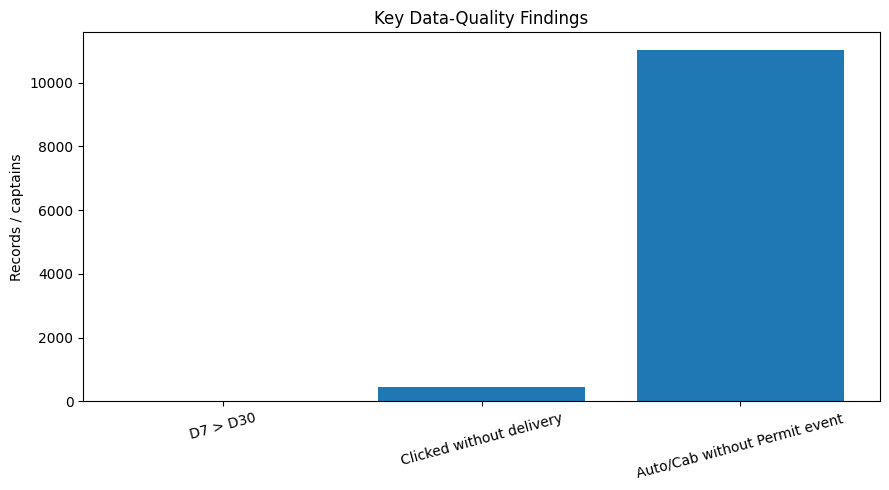

In [54]:
anomaly_counts = pd.Series({
    "D7 > D30": len(d7_gt_d30),
    "Clicked without delivery": len(click_without_delivery),
    "Auto/Cab without Permit event": len(missing_permit),
})

plt.figure(figsize=(9, 5))

plt.bar(
    anomaly_counts.index,
    anomaly_counts.values
)

plt.ylabel("Records / captains")
plt.title("Key Data-Quality Findings")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Why are we looking at this?

The audit identified several observations that require explicit treatment in downstream analysis. This chart summarizes their scale before we decide whether each represents a data error, expected business behavior, or an analytical limitation.

**What this tells us**

The three findings have very different interpretations. Missing Permit events are numerous but are not automatically erroneous because captains can leave the funnel before reaching Permit. In contrast, `orders_d7 > orders_d30` and clicks without recorded delivery are logically unusual and should be retained as data-quality flags.

The key principle is that anomaly size alone does not determine whether a record should be removed.

## 8. Airport Hourly Arithmetic Check

The airport analysis uses request, fulfillment, ETA, and supply fields. Before using them, verify the basic request arithmetic:

**requests = fulfilled_requests + unfulfilled_requests**

In [55]:
airport_arithmetic = (
    airport_hourly["fulfilled_requests"]
    + airport_hourly["unfulfilled_requests"]
    == airport_hourly["requests"]
)

In [56]:
print(
    "Airport zone-hour rows failing request arithmetic:",
    int((~airport_arithmetic).sum())
)

Airport zone-hour rows failing request arithmetic: 0


# Data Audit and Cleaning — Final Conclusion

## 1. Purpose

This notebook audited the raw datasets for structural integrity, business-rule consistency, document lifecycle correctness, cross-table relationships, temporal consistency, and known data-quality anomalies.

The objective was **not to aggressively clean the data by deleting unusual records**, but to determine which records are valid, which are anomalous, and which require special handling during downstream analysis.

---

## 2. Structural Integrity

The core tables passed the primary-key and duplicate checks:

* `captains`: **25,000** unique captain IDs.
* `approvals`: **25,000** unique captain IDs.
* `doc_events`: **186,282** unique event IDs.
* `activation`: **4,206** unique captain IDs.
* `airport_trips`: **60,000** unique trip IDs.
* `airport_hourly`: unique at the expected **zone × hour** grain.
* `nudges`: exactly one record per **captain × campaign** combination.

No full-row duplicate issue was identified.

This confirms that the tables can be joined at their intended grain without treating legitimate multi-event document histories as duplicate data.

---

## 3. Document Lifecycle

The document-event audit found that the lifecycle behaves consistently with the stated business process:

* No document events occurred before signup.
* Attempt numbers remained within **1–3**.
* No missing attempt numbers were detected within observed document sequences.
* No contradictory attempts containing both verification pass and fail were identified.
* Document progression followed the expected sequence:

**DL → RC → Aadhaar → Permit → Fitness → Insurance**

This is important because it means the downstream funnel can use the observed document progression with reasonable confidence.

---

## 4. Document Applicability

Permit is required only for **Auto and Cab** captains.

The audit identified **11,031 Auto/Cab captains without a Permit event**.

This should **not automatically be classified as bad data**.

A captain who drops before reaching the Permit stage would naturally have no Permit event.

Therefore:

> **Missing Permit ≠ invalid Permit data.**

The downstream funnel must distinguish between:

* captains who never reached the Permit stage, and
* captains who reached the Permit stage but failed or abandoned it.

This distinction is critical when identifying the largest fixable leak.

---

## 5. Approval → Activation Consistency

The raw data contains **4,206 approved captains**, and activation records are consistent with the approval table.

The important business distinction is between:

**Signup → Approval (A2O)**

and

**Signup → First Order (R2A)**.

Approval means the captain successfully completed the onboarding/approval process, whereas activation requires the captain to actually place a first order.

Therefore, approval alone does not guarantee that the captain becomes an active supply-side participant.

---

## 6. Temporal Consistency

The lifecycle checks found no impossible timestamp relationships.

In particular:

* Approval did not occur before signup.
* First order did not occur before signup.
* First order did not occur before approval.
* Document events did not occur after first order.

This gives confidence that the timestamp-based funnel logic is not being driven by obvious temporal inconsistencies.

---

## 7. Known Data-Quality Anomalies

Three important anomalies were retained for explicit handling:

### D7 vs D30

**7 records** have:

`orders_d7 > orders_d30`

This is unusual given the apparent cumulative interpretation of the metrics. These records should be flagged rather than silently corrected.

### Nudge Delivery

**457 records** have:

`clicked = 1` and `delivered = 0`

This is logically unusual and should be considered when interpreting campaign performance.

### Approval Metadata

Approval timestamp and stage fields contain substantial missingness.

Therefore, missing approval metadata should not automatically be interpreted as an unsuccessful onboarding outcome.

---

## 8. Airport Data

The airport hourly data also passed its core arithmetic check:

**requests = fulfilled requests + unfulfilled requests**

No reconciliation issue was identified.

The airport datasets should nevertheless remain analytically separate from the full onboarding cohort because they cover a different period:

* Onboarding: **January–June 2026**
* Airport marketplace: **May–June 2026**

---

## 9. What This Audit Tells Us About the Business Problem

The most important conclusion from the audit is that the low approved/active population is **not explained by an obvious database integrity problem**.

The raw data contains:

* **25,000 signups**
* **4,206 approvals**
* **19,062 captains marked as dropped in documents**
* **1,297 still in progress**
* **435 rejected**

The dominant observed outcome is therefore **document-stage dropout**.

But the audit deliberately stops short of saying *which document is the problem*.

That requires reconstructing the mature funnel.

---

## 10. Key Question for the Next Analysis

The central business question now becomes:

> **At which document transition are we losing the most captains, and how much of that loss is potentially fixable?**

The mature cohort contains **22,757 signups** with at least **14 days of observation**.

The downstream funnel shows:

| Stage     |   Captains | Conversion from previous stage |
| --------- | ---------: | -----------------------------: |
| Signup    | **22,757** |                              — |
| DL        | **20,136** |                      **88.5%** |
| RC        | **14,647** |                      **72.7%** |
| Aadhaar   | **13,093** |                      **89.4%** |
| Permit    | **10,439** |                      **79.7%** |
| Fitness   |  **7,752** |                      **74.3%** |
| Insurance |  **4,412** |                      **56.9%** |
| Approval  |  **3,998** |                      **90.6%** |

Overall mature-cohort Signup → Approval conversion is **17.6%**.

The largest absolute funnel loss occurs at:

> **DL → RC: 20,136 → 14,647 = 5,489 captains lost.**

This is the first major indication of where the business should investigate.

However, the later **Insurance → Approval** transition has the lowest stage conversion (**56.9%**), so the analysis should distinguish between:

* **largest absolute volume of captains lost**, and
* **lowest percentage conversion / highest relative leakage**.

Those are different business questions and can lead to different interventions.

---

## 11. Handover to the Next Notebook

The data is now sufficiently validated to move from **“Can we trust the data?”** to **“What is happening to the captains?”**

The next notebook should focus on the mature onboarding funnel and answer:

1. Where are captains being lost?
2. Which stage represents the largest fixable leak?
3. What failure reasons explain the leakage?
4. Which cities, vehicle types, acquisition channels, or captain segments are disproportionately affected?
5. What intervention would create the largest improvement in approved/active supply?

The goal is to turn a dataset showing **25,000 signups and only 4,206 raw approvals** into a concrete operational diagnosis.
